# Pokemon Diffusion: DDPM Implementation Lab

Repository for the Advanced Communications and Signal Processing Laboratory at Imperial College London.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/guyuxuan9/Diffusion_Experiments_Advanced_CSP_Lab_EEE_Imperial/blob/main/Practical_Project.ipynb)

## Rules ⚖️ 

### Logistics 📝 

* The goal is to implement an end-to-end diffusion model on the Pokemon dataset.
* Work in pairs. If needed, a group of 3 students will be created.
* Plagiarism is not allowed and may lead to serious consequences. However, you may discuss solutions with your classmates and take inspiration from open-source implementations.
* Small copied code snippets are allowed if clearly referenced.
* We recommend Python + PyTorch for the implementation.
* Your code should run on Google Colab and normal desktop computers with minimal setup effort.
* Submit your results via Canvas.

### How to Pass 🎓

* Implement a technically correct forward and backward process. Image quality is not the main grading criterion.
* Create animations (e.g., gifs) of both forward and backward process.
* Comment your code clearly and use proper variable names. 
* Set random seeds to make your results reproducible.
* Save your final model weights. 
* Show that the forward process approaches a standard normal distribution.
* We recommend following the denoising diffusion paradigm. Score-based or SDE approaches are also allowed.

### Bonus 🏆

For a bonus, you can extend the implementation in any creative way. Possibilities include:
* Conditioning: giving the model a label, such as “Fire” to control which type of Pokémon it generates.
* Using a latent diffusion approach instead of diffusion in the RGB/image space.

If you have any other idea you think is worth investigating: try it out!


### References 📚
Preliminaries 💡 
* [10 tricks for a better Google Colab experience](https://towardsdatascience.com/10-tips-for-a-better-google-colab-experience-33f8fe721b82)
* [Youtube: Deep Learning With PyTorch - Full Course (in case you need some PyTorch refreshments)](https://www.youtube.com/watch?v=c36lUUr864M&ab_channel=PatrickLoeber)
* [UvA PyTorch Tutorial](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial2/Introduction_to_PyTorch.html)
* [U-Net: Convolutional Networks for Biomedical Image Segmentation](https://link.springer.com/content/pdf/10.1007/978-3-319-24574-4_28.pdf)

Diffusion 🧨
* [What are Diffusion Models?](https://www.youtube.com/watch?v=fbLgFrlTnGU)
* [Tiny Diffusion Repo by tanelp (minimal example of a 2D diffusion)](https://github.com/tanelp/tiny-diffusion)
* [Youtube: Diffusion models from scratch in PyTorch](https://www.youtube.com/watch?v=a4Yfz2FxXiY&t=644s)
* [Youtube: Diffusion Models | PyTorch Implementation](https://www.youtube.com/watch?v=TBCRlnwJtZU&ab_channel=Outlier)
* [The Annotated Diffusion Model](https://huggingface.co/blog/annotated-diffusion)
* [Diffusion models explained in 4-difficulty levels](https://www.youtube.com/watch?v=yTAMrHVG1ew)
* [How AI Image Generators Work (Stable Diffusion / Dall-E) - Computerphile](https://www.youtube.com/watch?v=1CIpzeNxIhU)



Pokemon 🐲
* [Pokemon Images Dataset on Kaggle](https://www.kaggle.com/datasets/kvpratama/pokemon-images-dataset)
* [PokeGAN: Generating Fake Pokemon with a Generative Adversarial Network](https://blog.jovian.com/pokegan-generating-fake-pokemon-with-a-generative-adversarial-network-f540db81548d)
* [pokemon-ga by Zhenye Na (contains the dataset we are using)](https://github.com/Zhenye-Na/pokemon-gan)


# Setup

In [1]:
import sys
import subprocess
import tempfile
import shutil

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "-q", "--force-reinstall",
        "sympy==1.13.3"   # change version if needed
    ])

### Downloading the Data

In [2]:
from pathlib import Path

if not Path("pokemon").exists():
    with tempfile.TemporaryDirectory(prefix="pokemon_download_") as tmp:
        repo = Path(tmp) / "pokemon_diffusion"

        subprocess.run(
            ["git", "clone", "https://github.com/gerritgr/pokemon_diffusion", str(repo)],
            check=True,
        )

        shutil.copytree(repo / "pokemon", Path("pokemon"))

### Imports

In [3]:
%pip install imageio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100 # Set this to 300 to get better image quality
from PIL import Image # We use PIL to load images
import seaborn as sns
import imageio # to generate .gifs

# always good to have
import glob, random, os
import numpy as np

# the typical pytorch imports
import torch
import torchvision
from torchvision import transforms 
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torch import nn
from torch.nn import Conv2d
from torch.optim import Adam

### Hyperparameters

These are just random hyperparameters, play around with them.

In [5]:
IMG_SIZE = 32   # We assume images are square with IMG_SIZE*IMG_SIZE pixels, 16x16 works, too.
BATCH_SIZE = 256
TIMESTEPS = 100

# On Colab, go to Runtime -> Change runtime type to switch to GPU 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHANNELS = 3  # We use RGB images
DEVICE

device(type='cuda')

### Seeds
... to make everyting deterministic.

In [6]:
np.random.seed(42)
torch.random.manual_seed(42)
random.seed(42)
torch.cuda.manual_seed_all(42)
os.environ['PYTHONHASHSEED'] = '42'
torch.backends.cudnn.deterministic = True

### Utils

We start by defining some friendly little helpers. 

In [7]:
def image_to_tensor(image):
    """Convert a PIL image to a PyTorch tensor.

    Args:
        image (PIL.Image): The image to be converted.

    Returns:
        torch.Tensor: The converted PyTorch tensor.
    """
    # Define the image transformation pipeline
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Lambda(lambda t: (t - 0.5) * 2.) # update to [-1, 1] range
    ])

    # Apply the transformation pipeline to the image
    return transform(image)


def tensor_to_img(tensor):
    """Convert a PyTorch tensor to a PIL image.

    Args:
        tensor (torch.Tensor): The PyTorch tensor to be converted.

    Returns:
        PIL.Image: The converted PIL image.
    """
    # Define the tensor transformation pipeline
    transform = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1.) / 2.),
        transforms.Lambda(lambda t: torch.clamp(t, min=0., max=1.)),
        transforms.ToPILImage()
    ])

    # Apply the transformation pipeline to the tensor
    return transform(tensor)


def show_from_image_list(img_list, img_num=10, filename=None):
    """Show a grid of images from a list of images. Sample uniformly spaced images.
        (Alternativly, use make_grid from torchvision.utils)

    Args:
        img_list (list): The list of images to be displayed. Can be PIL or image tensors.
        img_num (int, optional): The number of images to be displayed. Default is 10.
        filename (str, optional): The name of the file to save the plot to. If None, the plot will not be saved. Default is None.
    """
    # Ensure that the number of images to be displayed is less than or equal to the number of images in the list
    img_num = min(len(img_list), img_num)

    # Get the index of the images to be displayed
    img_num_index = np.linspace(0, len(img_list)-1.0, num=img_num).astype(int)

    # Clear the current figure (if there is any)
    plt.clf()

    # Create a figure with 1 row and `img_num` columns
    fig, ax = plt.subplots(1, img_num, figsize=(15, 15), gridspec_kw={'width_ratios': [1] * img_num})

    # Iterate through the images to be displayed
    for i, idx in enumerate(img_num_index):
        img_i = img_list[idx]

        # Check if the image is a PyTorch tensor and convert it to PIL
        if isinstance(img_i, torch.Tensor):
            img_i = tensor_to_img(img_i)

        # Display the image
        ax[i].imshow(img_i)
        ax[i].axis('off')

    # Save the plot to a file if the filename is provided
    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches='tight')

    # Show the plot
    plt.show()


# Defining the Dataset and Loader

First, we create a PyTorch `Dataset` and `DataLoader` for the images in the image folder.

The `Dataset` loads individual images and can apply data augmentation on the fly. The `DataLoader` groups them into shuffled mini-batches for efficient training.

Our custom `Dataset` converts each image into a PyTorch tensor of shape $(3, \text{IMG\_SIZE}, \text{IMG\_SIZE})$ and scales pixel values to the range $[-1, 1]$.

In [8]:
from torch.utils.data import Dataset, DataLoader, IterableDataset, TensorDataset


class ImageDataset(Dataset):
  """A dataset for images that supports on-the-fly transformations (i.e., augmentations).

  Args:
      imgpaths (str, optional): The path pattern for the images. Default is "pokemon/*png".
  """

  def __init__(self, img_paths="pokemon/*png"):

    # You can/should play around with these. Which of the augmantation make sense? 
    self.on_the_fly_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomApply(torch.nn.ModuleList([transforms.RandomCrop(int(IMG_SIZE*0.8)),]), p=0.1),
    transforms.RandomAutocontrast(p=0.1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda t: torch.clamp(t, min=-1., max=1.)),
    ])

    self.img_list = list()
    for img_path in glob.glob(img_paths):
      # Turn the transparent part in the image to white following 
      # https://stackoverflow.com/questions/50898034/how-replace-transparent-with-a-color-in-pillow
      image = Image.open(img_path)
      rgba_image = Image.new("RGBA", image.size, "WHITE")
      rgba_image.paste(image, (0, 0), image)   
      rgb_image = rgba_image.convert('RGB')

      # Convert the PIL image to a tensor, where each value is in [-1,1].
      img_as_tensor = image_to_tensor(rgb_image)
      self.img_list.append(img_as_tensor)

  def __getitem__(self, index):
    """Get an image tensor from the dataset with on-the-fly transformation.

    Args:
        index (int): The index of the image tensor in the dataset.

    Returns:
        torch.Tensor: The image tensor with on-the-fly transformation.
    """
    img = self.img_list[index]
    img = self.on_the_fly_transform(img)

    return img
  
  def get_pil_image(self, index, with_random_augmentation=True):
    """Get a PIL image from the dataset with or without on-the-fly transformation.

    Args:
        index (int): The index of the PIL image in the dataset.
        with_random_augmentation (bool, optional): Whether to apply on-the-fly transformation. Default is True.

    Returns:
        PIL.Image: The PIL image with or without on-the-fly transformation.
    """
    if with_random_augmentation:
      return tensor_to_img(self.__getitem__(index))
    return tensor_to_img(self.img_list[index])

  def __len__(self):
    return len(self.img_list)


dataset = ImageDataset()

dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

C:\Users\ShimitsuKoi\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


In [9]:
# Note hat just grabbing an image from the dataset adds a random image augmentation.
# Generally speaking, this will be False. Try a few times.
torch.all(dataset[0] == dataset[0])  # torch.all test if all entries are True

tensor(True)

### Inspecting the Dataset

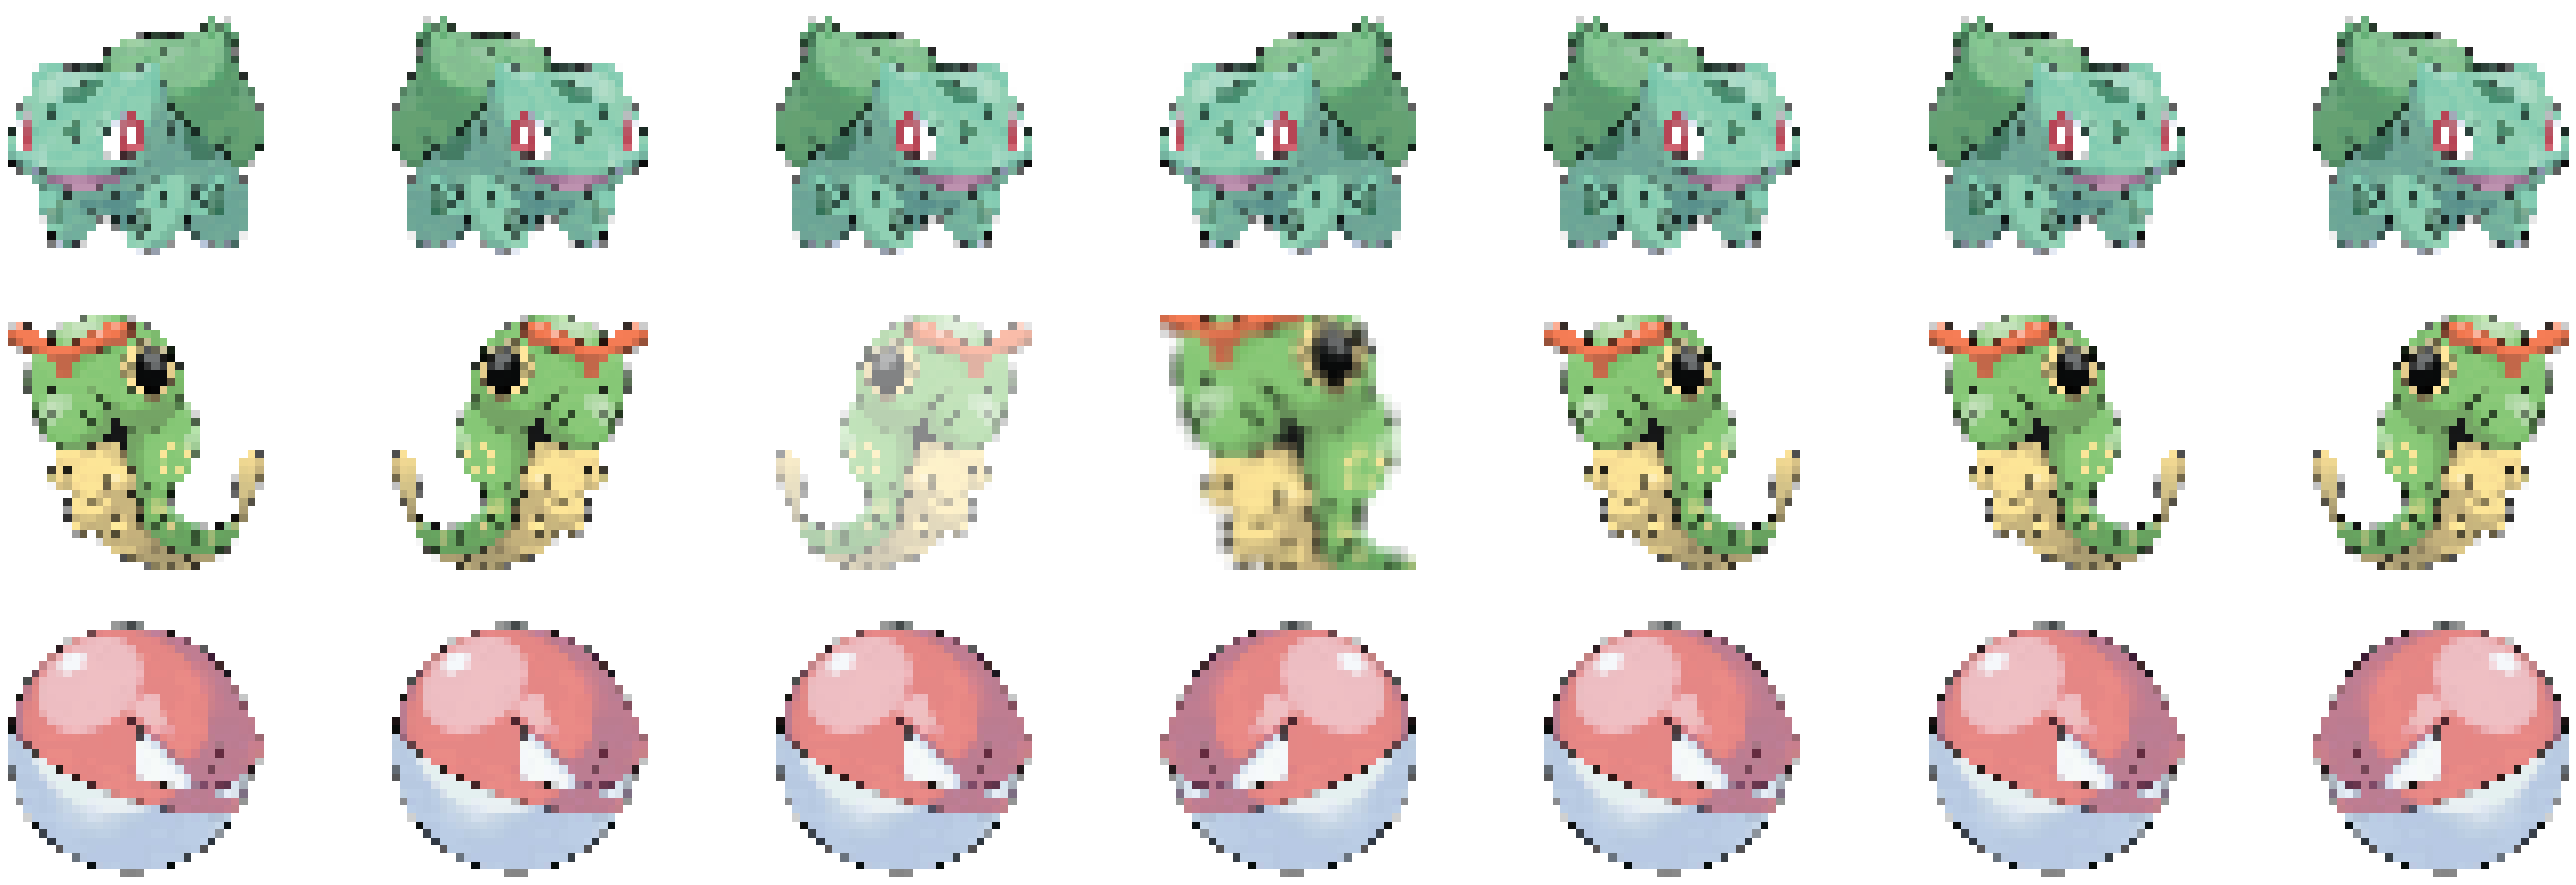

In [10]:
# Visualize the data

# Show seven versions of the first three Pokemons. 
images_per_row = 7
fig, axes = plt.subplots(3, images_per_row, figsize=(45, 15))

# Plotting each image in a subplot
for i, ax in enumerate(axes.flat):
    # The leftmost Pokemon is without augmentation (with_random_augmentation is False).
    with_random_augmentation = False if i % images_per_row == 0 else True
    ax.imshow(dataset.get_pil_image(i//images_per_row, with_random_augmentation=with_random_augmentation))
    ax.axis('off')

plt.savefig('dataset_summary.png', bbox_inches='tight')
plt.show()


Next, we visualize the frequency of each RGB value in the image dataset (before augmentation). After the forward process, this should look like three standard normal distributions.

In [11]:
# Create giant tensor with all images.
img_num = len(dataset.img_list)
tensor_with_all_images = torch.zeros((img_num, CHANNELS, IMG_SIZE, IMG_SIZE))
for i, img in enumerate(dataset.img_list):
  tensor_with_all_images[i,:,:,:] = img

# Save the pixel values of all images in 1D tensor for each channel. 
pixels_red = tensor_with_all_images[:,0,:,:].flatten().numpy()
pixels_green = tensor_with_all_images[:,1,:,:].flatten().numpy()
pixels_blue = tensor_with_all_images[:,2,:,:].flatten().numpy()

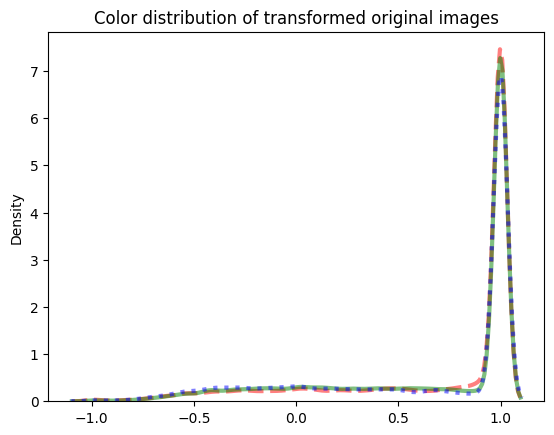

In [12]:
ax = sns.kdeplot(pixels_red, color="red", alpha=0.5, ls="--", lw=3)
sns.kdeplot(pixels_green, color="green", ax=ax, alpha=0.5, lw=3)
sns.kdeplot(pixels_blue, color="blue", ax=ax, alpha=0.5, ls=":", lw=3)
plt.title("Color distribution of transformed original images")
plt.savefig('color_distribution_original_images.png', dpi=300, bbox_inches='tight')

# Visualizing the Forward Process

C:\Users\ShimitsuKoi\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:173: UserWarning: 
NVIDIA GeForce RTX 5060 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5060 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(incompatible_device_warn.format(device_name, capability, " ".join(arch_list), device_name))


<Figure size 640x480 with 0 Axes>

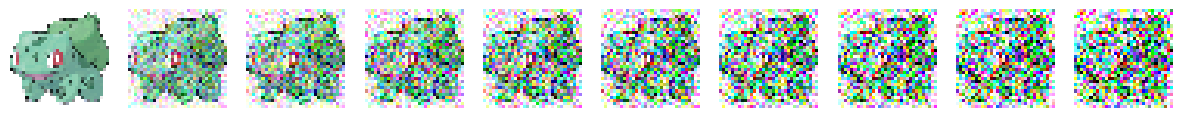

In [13]:
def one_step_forward(img, t):
  #
  # This is not correct!!! Fix it.
  #
  return img + torch.randn_like(img, device=DEVICE)*0.1

def create_forward_animation(dataset):
  img = dataset.img_list[0].to(DEVICE)
  img_list = list()
  # if TIMESTEPS is too large, you can use a subset
  img_list.append(tensor_to_img(img)) 
  for t in range(TIMESTEPS):
    img = one_step_forward(img, t=t)
    img_list.append(tensor_to_img(img)) 
  return img_list
  
img_list = create_forward_animation(dataset)

# the .gif file can get pretty large
imageio.mimsave("forward_animate.gif", img_list, fps=10) 
# we can also show the images inline
show_from_image_list(img_list, filename = 'forward_grid.png')


# Guided DDPM implementation lab

The animation above is an intentionally incorrect warm-up. From this point onward, build a denoising diffusion probabilistic model (DDPM) step by step.

By the end of the lab you should be able to:

1. construct a variance schedule;
2. sample any noisy state $x_t$ directly from a clean image $x_0$;
3. train a time-conditioned network to predict the added noise;
4. implement one reverse transition $p_\theta(x_{t-1}\mid x_t)$;
5. generate and inspect a complete reverse trajectory.

Cells marked `# TODO` contain the assessed implementation work. The surrounding code supplies tensor shapes, plotting, checkpoints, and training structure.

## 1. Diffusion schedule

We use a linear schedule, define $\beta_t$ between `BETA_START` and `BETA_END`. Let $\alpha_t = 1 - \beta_t$ and $\bar\alpha_t = \prod_{s=0}^{t}\alpha_s$. The posterior variance of $q(x_{t-1} \mid x_t, x_0)$ is $\tilde{\beta}_t = \beta_t \frac{1 - \bar\alpha_{t-1}}{1 - \bar\alpha_t},$ and $\bar\alpha_{-1}=1.$

The code below precomputes these values for use during diffusion. The schedule is provided so you can focus on implementing the forward and reverse processes.

**Extension**: Try a cosine schedule and compare the results.

In [14]:
# Keep this small while debugging. Increase it only after all checks pass.
NUM_DIFFUSION_STEPS = 1000
BETA_START = 1e-4
BETA_END = 2e-2
LEARNING_RATE = 2e-4


def make_linear_schedule(num_steps, beta_start=BETA_START, beta_end=BETA_END, device=DEVICE):
    """Precompute all scalar quantities used by forward and reverse diffusion."""
    betas = torch.linspace(beta_start, beta_end, num_steps, device=device)
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    alpha_bars_prev = F.pad(alpha_bars[:-1], (1, 0), value=1.0)
    posterior_variance = (
        betas * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)
    ).clamp(min=1e-20)

    return {
        "betas": betas,
        "alphas": alphas,
        "alpha_bars": alpha_bars,
        "alpha_bars_prev": alpha_bars_prev,
        "posterior_variance": posterior_variance,
    }


schedule = make_linear_schedule(NUM_DIFFUSION_STEPS)
print("First/last beta:", schedule["betas"][0].item(), schedule["betas"][-1].item())
print("Final alpha_bar:", schedule["alpha_bars"][-1].item())

# TODO (extension): implement a cosine schedule and compare alpha_bar curves.

First/last beta: 9.999999747378752e-05 0.019999999552965164
Final alpha_bar: 4.035830352222547e-05


## 2. Forward diffusion

During training, an arbitrary noisy state can be sampled directly:

$x_t = \sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\epsilon$, where $\epsilon\sim\mathcal{N}(0,I)$.

Implement this equation below. Keep every tensor batched with shape `(B, C, H, W)`. The helper function reshapes the timestep-dependent values so they broadcast correctly across each image.

In [15]:
def extract(values, timesteps, x_shape):
    """Gather one schedule value per example and reshape it for broadcasting."""
    timesteps = timesteps.long()
    gathered = values.gather(0, timesteps)
    return gathered.reshape(timesteps.shape[0], *((1,) * (len(x_shape) - 1)))


def q_sample(x0, timesteps, schedule, noise=None):
    """Sample q(x_t | x_0), returning both the noisy image and target noise."""
    if noise is None:
        noise = torch.randn_like(x0)

    # TODO 1: extract alpha_bar_t for every item in the batch.
    alpha_bar_t = extract(schedule["alpha_bars"], timesteps, x0.shape)
    sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)

    # √TODO 2: combine x0 and noise using the closed-form forward equation.
    x_t = sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * noise

    if x_t is None:
        raise NotImplementedError("Complete TODO 1 and TODO 2 in q_sample.")
    return x_t, noise


def check_forward_shapes():
    """Run this after implementing q_sample."""
    batch = next(iter(dataloader))[:4].to(DEVICE)
    timesteps = torch.tensor(
        [0, 1, NUM_DIFFUSION_STEPS // 2, NUM_DIFFUSION_STEPS - 1],
        device=DEVICE,
    )
    noisy, noise = q_sample(batch, timesteps, schedule)
    assert noisy.shape == batch.shape
    assert noise.shape == batch.shape
    assert torch.isfinite(noisy).all()
    print("Forward-process shape and finite-value checks passed.")


# Uncomment after TODO 1-2.
check_forward_shapes()

Forward-process shape and finite-value checks passed.


C:\Users\ShimitsuKoi\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


### Visual checkpoints

Use the same clean image and apply the forward diffusion process at several time steps between $t=0$ and $t=999$. As $t$ increases, the image should gradually approach Gaussian noise. Then compare the terminal RGB distributions with samples from a standard Gaussian.

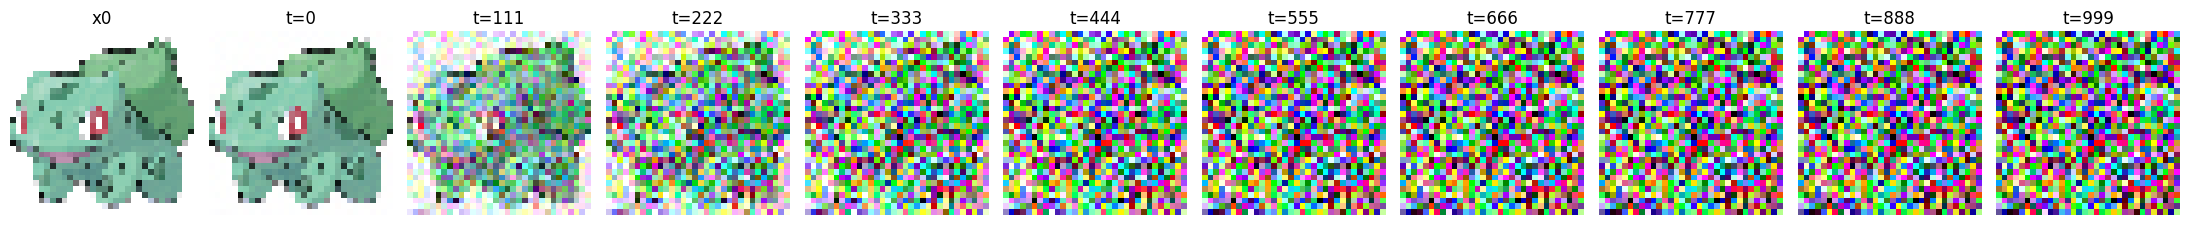

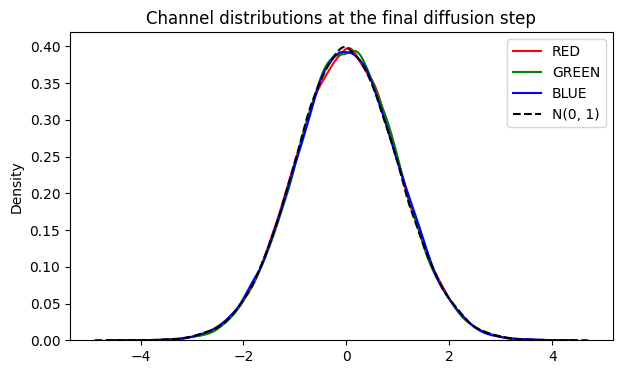

In [16]:
@torch.no_grad()
def plot_forward_trajectory(x0, schedule, number_of_frames=10, filename="forward_process_student.png"):
    x0 = x0.unsqueeze(0).to(DEVICE) if x0.ndim == 3 else x0.to(DEVICE)
    steps = torch.linspace(0, NUM_DIFFUSION_STEPS - 1, number_of_frames).long()
    frames, labels = [x0[0].cpu()], ["x0"]
    fixed_noise = torch.randn_like(x0)

    for step in steps:
        t = torch.tensor([step.item()], device=DEVICE)
        x_t, _ = q_sample(x0, t, schedule, noise=fixed_noise)
        frames.append(x_t[0].cpu())
        labels.append(f"t={step.item()}")

    fig, axes = plt.subplots(1, len(frames), figsize=(2 * len(frames), 2.3))
    for axis, frame, label in zip(axes, frames, labels):
        axis.imshow(tensor_to_img(frame))
        axis.set_title(label)
        axis.axis("off")
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()
    return frames


def save_forward_gif(frames, filename="forward_process_student.gif", fps=8):
    imageio.mimsave(filename, [tensor_to_img(frame) for frame in frames], fps=fps)


@torch.no_grad()
def plot_terminal_channel_distribution(dataset, schedule, image_count=50):
    count = min(image_count, len(dataset))
    x0 = torch.stack(dataset.img_list[:count]).to(DEVICE)
    final_t = torch.full(
        (count,), NUM_DIFFUSION_STEPS - 1, device=DEVICE, dtype=torch.long
    )
    x_T, _ = q_sample(x0, final_t, schedule)
    pixels = x_T.detach().cpu()

    plt.figure(figsize=(7, 4))
    for channel, color in enumerate(("red", "green", "blue")):
        sns.kdeplot(
            pixels[:, channel].flatten().numpy(),
            color=color,
            label=color.upper(),
        )
    sns.kdeplot(
        torch.randn(100_000).numpy(),
        color="black",
        linestyle="--",
        label="N(0, 1)",
    )
    plt.title("Channel distributions at the final diffusion step")
    plt.legend()
    plt.show()


# Uncomment after TODO 1-2.
forward_frames = plot_forward_trajectory(dataset.img_list[0], schedule)
save_forward_gif(forward_frames)
plot_terminal_channel_distribution(dataset, schedule)

## 3. Time-conditioned noise predictor

The compact network below takes the noisy image $x_t$ and the time step $t$ as input and predicts the added noise $\epsilon$.

A compact model is provided so you can focus on the diffusion equations and the training and sampling loops. Once the full pipeline works, you can replace it with a larger U-Net from the reference material.

In [17]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.embedding_dim = embedding_dim

    def forward(self, timesteps):
        half_dim = self.embedding_dim // 2
        scale = np.log(10_000) / (half_dim - 1)
        frequencies = torch.exp(
            -scale * torch.arange(half_dim, device=timesteps.device)
        )
        angles = timesteps.float()[:, None] * frequencies[None, :]
        return torch.cat((angles.sin(), angles.cos()), dim=1)


class TimeConditionedBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.time_projection = nn.Linear(time_dim, out_channels)
        self.activation = nn.SiLU()

    def forward(self, x, time_embedding):
        h = self.activation(self.norm1(self.conv1(x)))
        h = h + self.time_projection(time_embedding)[:, :, None, None]
        return self.activation(self.norm2(self.conv2(h)))


class TinyDenoiser(nn.Module):
    """Small U-Net-like model that predicts epsilon from (x_t, t)."""
    def __init__(self, image_channels=CHANNELS, base_channels=64, time_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(64),
            nn.Linear(64, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.input_projection = nn.Conv2d(image_channels, base_channels, 3, padding=1)
        self.down_block = TimeConditionedBlock(base_channels, base_channels, time_dim)
        self.downsample = nn.Conv2d(
            base_channels, base_channels * 2, 4, stride=2, padding=1
        )
        self.middle_block = TimeConditionedBlock(
            base_channels * 2, base_channels * 2, time_dim
        )
        self.upsample = nn.ConvTranspose2d(
            base_channels * 2, base_channels, 4, stride=2, padding=1
        )
        self.up_block = TimeConditionedBlock(
            base_channels * 2, base_channels, time_dim
        )
        self.output_projection = nn.Conv2d(base_channels, image_channels, 1)

    def forward(self, x_t, timesteps):
        time_embedding = self.time_mlp(timesteps)
        x = self.input_projection(x_t)
        skip = self.down_block(x, time_embedding)
        x = self.downsample(skip)
        x = self.middle_block(x, time_embedding)
        x = self.upsample(x)
        x = torch.cat((x, skip), dim=1)
        x = self.up_block(x, time_embedding)
        return self.output_projection(x)


model = TinyDenoiser().to(DEVICE)
test_images = torch.randn(4, CHANNELS, IMG_SIZE, IMG_SIZE, device=DEVICE)
test_times = torch.randint(0, NUM_DIFFUSION_STEPS, (4,), device=DEVICE)
assert model(test_images, test_times).shape == test_images.shape
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 802,947


## 4. Training objective

For every mini-batch, sample a time step for each image, construct corresponding noisy image $x_t$, predict the added noise, and minimize mean-squared error between the predicted and true noise. Complete the objective for a single batch first. The full training loop is provided.

In [18]:
def diffusion_loss(model, x0, schedule):
    batch_size = x0.shape[0]

    # TODO 3: sample an independent integer time step for every image.
    timesteps = torch.randint(
        low=0,
        high=schedule["betas"].shape[0],
        size=(batch_size,),
        device=x0.device,
        dtype=torch.long,
    )

    target_noise = torch.randn_like(x0)

    # TODO 4：use q_sample to create x_t with target_noise.
    x_t, _ = q_sample(x0, timesteps, schedule, noise=target_noise)

    # TODO 5：predict the noise and compute mean-squared error.
    predicted_noise = model(x_t, timesteps)
    loss = F.mse_loss(predicted_noise, target_noise)

    if loss is None:
        raise NotImplementedError("Complete TODO 3-5 in diffusion_loss.")
    return loss


def train_one_epoch(model, dataloader, optimizer, schedule):
    model.train()
    running_loss = 0.0
    for x0 in dataloader:
        x0 = x0.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = diffusion_loss(model, x0, schedule)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x0.shape[0]
    return running_loss / len(dataloader.dataset)

In [19]:
# Training is opt-in so "Run all" does not launch a long experiment.
RUN_TRAINING = True
TRAINING_EPOCHS = 70
CHECKPOINT_PATH = "pokemon_ddpm_student.pt"

optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

if RUN_TRAINING:
    loss_history = []
    for epoch in range(TRAINING_EPOCHS):
        epoch_loss = train_one_epoch(model, dataloader, optimizer, schedule)
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch + 1:03d}/{TRAINING_EPOCHS}: loss={epoch_loss:.6f}")

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss_history": loss_history,
            "num_diffusion_steps": NUM_DIFFUSION_STEPS,
        },
        CHECKPOINT_PATH,
    )
    print("Saved:", CHECKPOINT_PATH)

C:\Users\ShimitsuKoi\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Epoch 001/70: loss=0.948971
Epoch 002/70: loss=0.617214
Epoch 003/70: loss=0.422616
Epoch 004/70: loss=0.334657
Epoch 005/70: loss=0.264607
Epoch 006/70: loss=0.222009
Epoch 007/70: loss=0.203654
Epoch 008/70: loss=0.184084
Epoch 009/70: loss=0.171058
Epoch 010/70: loss=0.162907
Epoch 011/70: loss=0.151042
Epoch 012/70: loss=0.155118
Epoch 013/70: loss=0.146651
Epoch 014/70: loss=0.136306
Epoch 015/70: loss=0.138526
Epoch 016/70: loss=0.124924
Epoch 017/70: loss=0.128075
Epoch 018/70: loss=0.121317
Epoch 019/70: loss=0.120154
Epoch 020/70: loss=0.108073
Epoch 021/70: loss=0.104189
Epoch 022/70: loss=0.105251
Epoch 023/70: loss=0.116456
Epoch 024/70: loss=0.111323
Epoch 025/70: loss=0.092182
Epoch 026/70: loss=0.104209
Epoch 027/70: loss=0.099277
Epoch 028/70: loss=0.105329
Epoch 029/70: loss=0.095800
Epoch 030/70: loss=0.097383
Epoch 031/70: loss=0.094902
Epoch 032/70: loss=0.086447
Epoch 033/70: loss=0.094413
Epoch 034/70: loss=0.089142
Epoch 035/70: loss=0.087262
Epoch 036/70: loss=0

## 5. Reverse diffusion

Start from $x_T\sim\mathcal{N}(0,I)$, and repeatedly estimate $x_{t-1}$. For a noise-prediction model, $\mu_\theta(x_t,t)=\frac{1}{\sqrt{\alpha_t}}\left(x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\epsilon_\theta(x_t,t)\right)$. Recall that the reverse-process transition is $p_\theta(x_{t-1} \mid x_t)=\mathcal{N}\left(\mu_\theta(x_t,t),\,\tilde{\beta}_t I\right).$ At each step, use the precomputed posterior variance $\tilde{\beta}_t$ to add the stochastic noise term. At $t=0$, return the predicted mean without adding new noise.

In [20]:
@torch.no_grad()
def p_sample(model, x_t, step, schedule):
    """Sample one reverse transition from x_t to x_(t-1)."""
    batch_size = x_t.shape[0]
    timesteps = torch.full(
        (batch_size,), step, device=x_t.device, dtype=torch.long
    )

    beta_t = extract(schedule["betas"], timesteps, x_t.shape)
    alpha_t = extract(schedule["alphas"], timesteps, x_t.shape)
    alpha_bar_t = extract(schedule["alpha_bars"], timesteps, x_t.shape)
    predicted_noise = model(x_t, timesteps)

    # TODO 6: implement the DDPM reverse-process mean shown above.
    # model_mean = (x_t - beta_t / torch.sqrt(1.0 - alpha_bar_t) * predicted_noise) / torch.sqrt(alpha_t)
    alpha_bar_prev_t = extract(schedule["alpha_bars_prev"], timesteps, x_t.shape)
    predicted_x0 = (
        x_t - torch.sqrt(1.0 - alpha_bar_t) * predicted_noise
    ) / torch.sqrt(alpha_bar_t)
    predicted_x0 = predicted_x0.clamp(-1.0, 1.0)
    
    if step == 0:
        return predicted_x0
    
    model_mean = (
        beta_t * torch.sqrt(alpha_bar_prev_t) / (1.0 - alpha_bar_t) * predicted_x0
        + torch.sqrt(alpha_t) * (1.0 - alpha_bar_prev_t)
          / (1.0 - alpha_bar_t) * x_t
    )
    if model_mean is None:
        raise NotImplementedError("Complete TODO 6 in p_sample.")

    if step == 0:
        return model_mean

    posterior_variance_t = extract(
        schedule["posterior_variance"], timesteps, x_t.shape
    )
    reverse_noise = torch.randn_like(x_t)

    # TODO 7: combine the mean, posterior standard deviation, and reverse_noise.
    x_previous = model_mean + torch.sqrt(posterior_variance_t) *  reverse_noise
    if x_previous is None:
        raise NotImplementedError("Complete TODO 7 in p_sample.")
    return x_previous

<Figure size 640x480 with 0 Axes>

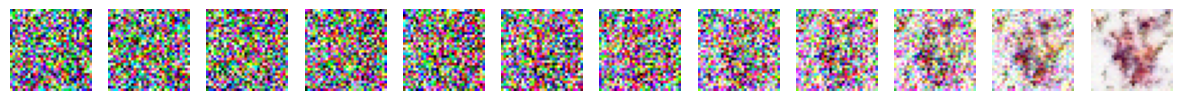

In [21]:
@torch.no_grad()
def sample_images(model, schedule, batch_size=1, record_every=10):
    """Run the reverse chain and retain frames for visualization."""
    model.eval()
    x = torch.randn(batch_size, CHANNELS, IMG_SIZE, IMG_SIZE, device=DEVICE)
    frames = [x[0].detach().cpu()]

    for step in reversed(range(NUM_DIFFUSION_STEPS)):
        x = p_sample(model, x, step, schedule)
        if step % record_every == 0 or step == 0:
            frames.append(x[0].detach().cpu())
    return x, frames


def show_reverse_trajectory(frames, filename="reverse_process_student.png"):
    show_from_image_list(
        frames, img_num=min(12, len(frames)), filename=filename
    )


def save_reverse_gif(frames, filename="reverse_process_student.gif", fps=8):
    imageio.mimsave(filename, [tensor_to_img(frame) for frame in frames], fps=fps)


# Uncomment after training and TODO 6-7.
generated_batch, reverse_frames = sample_images(model, schedule)
show_reverse_trajectory(reverse_frames)
save_reverse_gif(reverse_frames)

## 6. Architecture challenge: improve the denoiser

The `TinyDenoiser` is deliberately small. Design a stronger time-conditioned denoiser, while keeping the same interface, `model(x_t, timesteps)`, and the same output shape as `x_t`.

Make at least **two meaningful architectural improvements**, such as:
- Residual blocks
- More channels
- Bottleneck attention
- Stronger time conditioning.

In your formal report, include an **architectural diagram** showing:
- Data flow and the time conditioning
- Resolution changes
- Skip connections or concatenations
- Main activation tensor shape using $B \times C \times H \times W$ (and $B \times D$ for the time embedding)

Compare the original and improved models using:
- Parameter count
- Training-loss curves
- Equally-sized grids with the same sampling settings.

For a fair compairison, keep the dataset, diffusion schedule, optimizer, training updates, seed, and sampling procedure fixed.

In [22]:
class ResidualBlock(TimeConditionedBlock):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__(in_channels, out_channels, time_dim)

        self.skip = (
            nn.Identity()
            if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, 1)
        )

    def forward(self, x, time_embedding):
        return super().forward(x, time_embedding) + self.skip(x)
        
class ImprovedDenoiser(TinyDenoiser):
    def __init__(self, image_channels=CHANNELS):
        # Update1: More channels
        super().__init__(
            image_channels=image_channels,
            base_channels=96,
        )

        # Update2: Residual blocks
        self.down_block = ResidualBlock(96, 96, 128)
        self.middle_block = ResidualBlock(192, 192, 128)
        self.up_block = ResidualBlock(192, 96, 128)

    def forward(self, x_t, timesteps):
        return super().forward(x_t, timesteps)


improved_model = ImprovedDenoiser().to(DEVICE)

with torch.no_grad():
    improved_prediction = improved_model(test_images, test_times)

assert improved_prediction.shape == test_images.shape

print(f"Baseline parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Improved parameters: {sum(p.numel() for p in improved_model.parameters()):,}")


# Instantiate and check your model after completing TODO 8-9.
improved_model = ImprovedDenoiser().to(DEVICE)
improved_prediction = improved_model(test_images, test_times)
assert improved_prediction.shape == test_images.shape
print(f"Baseline parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Improved parameters: {sum(p.numel() for p in improved_model.parameters()):,}")

Baseline parameters: 802,947
Improved parameters: 1,766,563
Baseline parameters: 802,947
Improved parameters: 1,766,563


**Changes from `TinyDenoiser`:**

> _Describe the architectural changes you made._
>

**Justification and hypothesis:**

> _Explain why each change could improve denoising or sample quality, and state what evidence would support your hypothesis._
>

**Results and interpretation:**

> _Compare parameter counts, loss curves, and generated samples. Did the evidence support your hypothesis? Discuss quality gains as well as compute or memory costs._
>

## 7. Questions and answers

Answer each question in the space provided.

### Q1. Why can training jump directly from $x_0$ to a randomly selected $x_t$ instead of simulating every earlier forward step?

**A1.**

The forward process has a closed-form distribution:
$$
x_t=\sqrt{\bar{\alpha}_t}x_0+\sqrt{1-\bar{\alpha}_t}\epsilon,
\qquad \epsilon\sim\mathcal N(0,I).
$$Therefore, we can sample any $x_t$ directly without calculating the intermediate steps, making training more efficient.

### Q2. Why must the denoiser receive the time step $t$?

**A2.**

The noise level changes with $t$. Providing the timestep helps the denoiser understand how noisy the input is and predict the appropriate noise at each stage.

### Q3. What changes in the reverse update at $t=0$, and why?

**A3.**

At $t=0$, the reverse update returns the predicted mean without adding random noise. This is the final denoising step, and the theoretical posterior variance is zero.

### Q4. Does the terminal forward distribution look like a standard normal distribution? Cite evidence from your plot.

**A4.**

Yes. The terminal RGB distributions closely overlap the standard normal reference curve. They are approximately centred at zero and have a similar spread, supporting convergence towards $\mathcal N(0,1)$.

### Q5. What failure modes or limitations do you observe in the generated samples?

**A5.**

Some generated samples have blurred edges, distorted shapes, or residual noise. Fine details are also missing. Possible explanations include limited model capacity, the small dataset, and insufficient training.

### Q6. Apart from your architecture changes, which one change would you test next? Schedule, objective, augmentation, or training duration? and what is your hypothesis?

**A6.**

I would increase the training duration, for example from 20 to 40 epochs, while keeping other settings fixed. My hypothesis is that additional training will improve noise prediction and produce clearer shapes. I would compare loss curves and samples generated using the same sampling seeds.